<a href="https://colab.research.google.com/github/Istiak-Ahmed78/Adaptive-Defense-Against-Packet-Mutation/blob/development/Working_Attack_code_and_final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, access your file


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Dataset/UNSW_NB15_training-set.csv')

In [ ]:
import pandas as pd

def remove_non_numeric_features(df):
    # Select only columns with numeric data types
    numeric_df = df.select_dtypes(include=['number'])

    # Optional: Report which columns were removed
    removed_cols = set(df.columns) - set(numeric_df.columns)
    if removed_cols:
        print(f"Removed non-numeric columns: {', '.join(removed_cols)}")

    return numeric_df

In [ ]:
clean_df = remove_non_numeric_features(df)

Removed non-numeric columns: proto, state, service, attack_cat


In [ ]:
clean_df.head()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,1,0.121478,6,4,258,172,74.087490,252,254,14158.942380,...,1,1,1,0,0,0,1,1,0,0
1,2,0.649902,14,38,734,42014,78.473372,62,252,8395.112305,...,1,1,2,0,0,0,1,6,0,0
2,3,1.623129,8,16,364,13186,14.170161,62,252,1572.271851,...,1,1,3,0,0,0,2,6,0,0
3,4,1.681642,12,12,628,770,13.677108,62,252,2740.178955,...,1,1,3,1,1,0,2,1,0,0
4,5,0.449454,10,6,534,268,33.373826,254,252,8561.499023,...,2,1,40,0,0,0,2,39,0,0


In [ ]:
clean_df.columns

Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Load a credit card fraud dataset (example)
# In this dataset, 'Class' is the target: 0 = normal transaction, 1 = fraudulent
df = clean_df.copy()


print(df.columns)

df.head()

df.head()

# Check class imbalance
print("Class distribution before SMOTE:")
print(df['label'].value_counts())
# Might show something like: 0: 284,315 (normal transactions), 1: 492 (fraudulent)

# Prepare features and target
X = df.drop('label', axis=1)
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a model without SMOTE
model_no_smote = RandomForestClassifier(random_state=42)
model_no_smote.fit(X_train, y_train)
y_pred_no_smote = model_no_smote.predict(X_test)

print("Model performance WITHOUT SMOTE:")
print(classification_report(y_test, y_pred_no_smote))
# Likely shows high overall accuracy but poor recall on class 1 (frauds)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())
# Should show balanced classes

# Train a new model with SMOTE-enhanced data
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)

print("Model performance WITH SMOTE:")
print(classification_report(y_test, y_pred_smote))
# Should show improved recall for class 1 (frauds)

# Save the balanced data to a CSV file
# First, convert X_train_smote to DataFrame with original column names
balanced_df = pd.DataFrame(X_train_smote, columns=X.columns)

# Then add the target column
balanced_df['label'] = y_train_smote

# Sample 400 attack and 400 non-attack instances
attack_samples = balanced_df[balanced_df['label'] == 1].sample(n=400, random_state=42)
non_attack_samples = balanced_df[balanced_df['label'] == 0].sample(n=400, random_state=42)

# Concatenate and shuffle the sampled data
balanced_subset_df = pd.concat([attack_samples, non_attack_samples]).sample(frac=1, random_state=42)


# Save to CSV
output_file = 'balanced_data.csv'
balanced_subset_df.to_csv(output_file, index=False)
print(f"\nBalanced data saved to '{output_file}'")

# Optionally, save the test data for later use
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df['label'] = y_test
test_df.to_csv('test_data.csv', index=False)
print(f"Test data saved to 'test_data.csv'")

# Print examples of synthetic data
print("\nExamples of original minority class samples:")
original_minority = df[df['label'] == 1].head(2)
print(original_minority)

print("\nExamples of synthetic minority class samples after SMOTE:")
synthetic_minority = balanced_subset_df[balanced_subset_df['label'] == 1].iloc[-2:]
print(synthetic_minority)

Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')
Class distribution before SMOTE:
label
1    119341
0     56000
Name: count, dtype: int64
Model performance WITHOUT SMOTE:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     16772
           1       0.98      1.00      0.99     35831

    accuracy                           0.99     52603
   macro avg       0.99      0.98      0.99     52603
weighted avg       0.99      0.99      0.99     52603

Class 

# Finding important features

Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')
Dataset Shape: (800, 41)

Feature names:
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mth

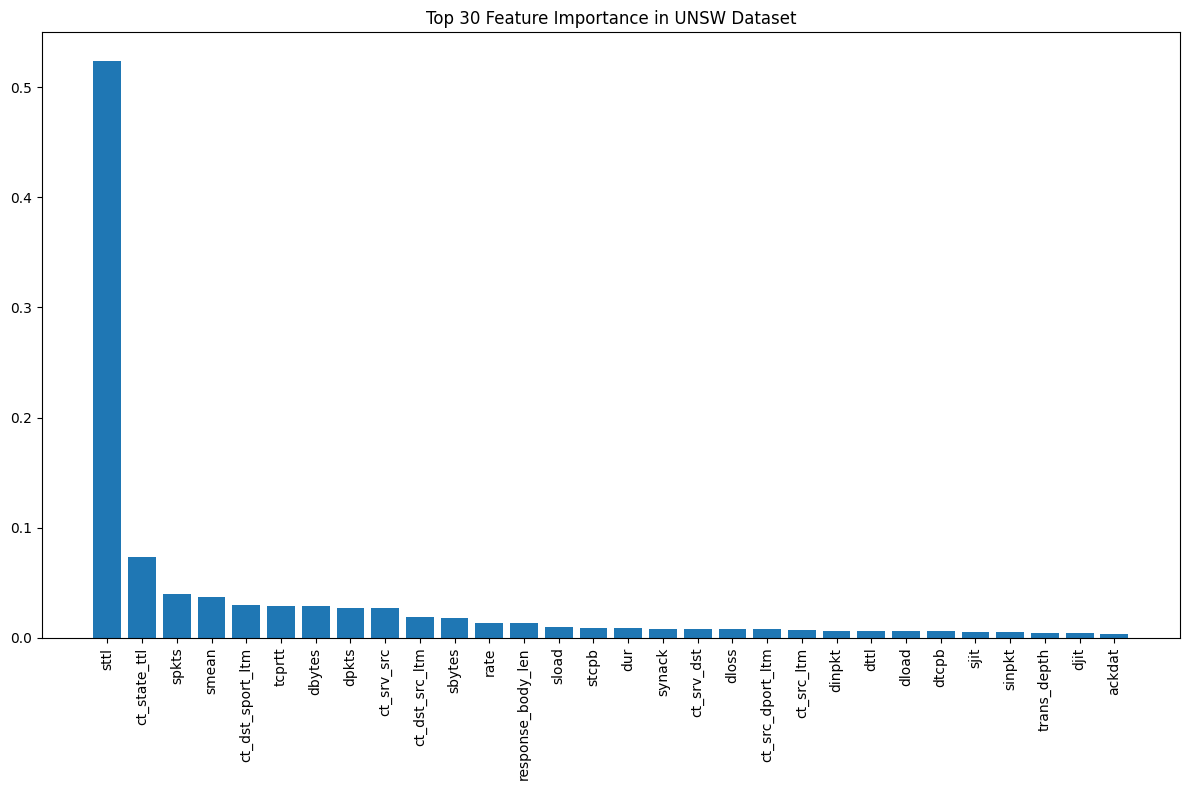


Full Model Performance:
Accuracy: 0.91875
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        80
           1       0.94      0.90      0.92        80

    accuracy                           0.92       160
   macro avg       0.92      0.92      0.92       160
weighted avg       0.92      0.92      0.92       160


Selected Features Model Performance:
Accuracy: 0.91875
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        80
           1       0.94      0.90      0.92        80

    accuracy                           0.92       160
   macro avg       0.92      0.92      0.92       160
weighted avg       0.92      0.92      0.92       160


Selected features saved to 'selected_features_unsw.csv'


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Load the UNSW-NB15 dataset
# Adjust the file path as needed for your environment
df = pd.read_csv('/content/balanced_data.csv')
print(df.columns)

df.head()

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFeature names:")
print(df.columns.tolist())

# Preprocess the data
# Assuming 'label' or 'attack_cat' is your target column
# For binary classification (normal vs. attack)
X = df.drop(['label', 'id'], axis=1, errors='ignore')  # Adjust column names as needed
y = df['label']  # Adjust target column name as needed

# Handle categorical features if present
X = pd.get_dummies(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBClassifier(
    objective='binary:logistic' if len(np.unique(y)) == 2 else 'multi:softprob',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# Get feature importance
feature_importance = model.feature_importances_
features = X.columns

# Create DataFrame of features and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Display top 20 features
print("\nTop 30 most important features:")
print(feature_importance_df.head(30))  # You can change importance feature number

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.bar(feature_importance_df['Feature'].head(30), feature_importance_df['Importance'].head(30)) # You can change importance feature number
plt.xticks(rotation=90)
plt.title('Top 30 Feature Importance in UNSW Dataset')
plt.tight_layout()
plt.show()

# Select top N features (e.g., top 20)
top_features = feature_importance_df['Feature'].head(30).tolist() # You can change importance feature number
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Train a new model with selected features
model_selected = xgb.XGBClassifier(
    objective='binary:logistic' if len(np.unique(y)) == 2 else 'multi:softprob',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
model_selected.fit(X_train_selected, y_train)

# Evaluate full model
y_pred_full = model.predict(X_test)
print("\nFull Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_full))
print(classification_report(y_test, y_pred_full))

# Evaluate model with selected features
y_pred_selected = model_selected.predict(X_test_selected)
print("\nSelected Features Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_selected))
print(classification_report(y_test, y_pred_selected))

# Save selected features to CSV
selected_features_df = pd.DataFrame({'Selected_Features': top_features})
selected_features_df.to_csv('selected_features_unsw.csv', index=False)
print("\nSelected features saved to 'selected_features_unsw.csv'")



In [ ]:
# Create a new dataframe with only the selected features and the target variable
selected_df = df[top_features + ['label']]

# Save the new dataframe to a CSV file
output_selected_file = 'unsw_selected_features.csv'
selected_df.to_csv(output_selected_file, index=False)

print(f"New dataset with selected features saved to '{output_selected_file}'")

# Display the head of the new dataframe
display(selected_df.head())

New dataset with selected features saved to 'unsw_selected_features.csv'


,sttl,ct_state_ttl,spkts,smean,ct_dst_sport_ltm,tcprtt,dbytes,dpkts,ct_srv_src,ct_dst_src_ltm,...,dinpkt,dttl,dload,dtcpb,sjit,sinpkt,trans_depth,djit,ackdat,label
0,31,0,19,86,1,0.000697,2389,21,7,2,...,16.538012,29,770625.558093,1930434364,1240.545449,18.145,0,1179.394212,0.000134,0
1,31,0,2,73,1,0.000000,178,2,4,2,...,0.006198,29,709965.106233,0,0.000000,0.001,0,0.000000,0.000000,0
2,254,2,2,100,5,0.000000,0,0,14,17,...,0.000000,0,0.000000,0,0.000000,0.004,0,0.000000,0.000000,1
3,254,2,2,39,1,0.000000,0,0,5,3,...,0.000000,0,0.000000,0,0.000000,0.005,0,0.000000,0.000000,0
4,254,2,2,100,1,0.000000,0,0,4,4,...,0.000000,0,0.000000,0,0.000000,0.001,0,0.000000,0.000000,1


In [ ]:
# Count the occurrences of attack (label=1) and non-attack (label=0)
attack_stats = selected_df['label'].value_counts()

print("Attack and Non-Attack Statistics in Selected Dataset:")
print(attack_stats)

Attack and Non-Attack Statistics in Selected Dataset:
label
0    400
1    400
Name: count, dtype: int64


In [ ]:
# # Ensure 'label' column exists
# if 'label' not in new_df.columns:
#     print("Error: 'label' column not found in the dataset.")
# else:
#     print(f"Loaded dataset with {new_df.shape[1]} features (including label)")

#     # Split data for training a detector model and generating adversarial examples
#     X = new_df.drop('label', axis=1)
#     y = new_df['label']  # Assuming label=1 for attack samples used in ALMA

In [ ]:
selected_df.shape

(800, 31)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi

Adversarial packets saved to 'adversarial_packet.csv'


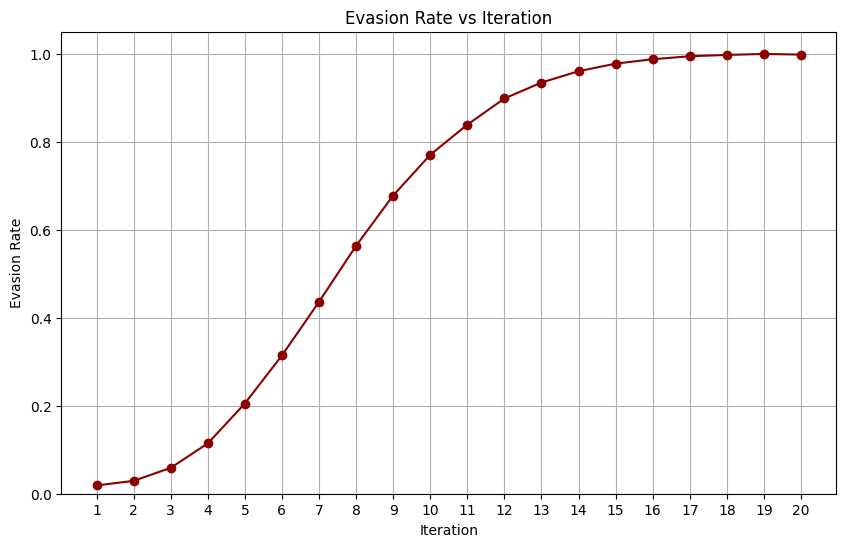

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# --- Configuration ---
alpha = 0.5
N = 20       # Number of iterations (generations)
M = 10       # Population size
evasion_threshold = 0.5  # consider a packet evaded if detected < 50%

# --- Data Setup ---
features = top_features  # already selected top 30
X = selected_df[features]
y = selected_df['label']

# Scale the data before splitting for NIDS training
scaler_nids = StandardScaler()
X_scaled_nids = scaler_nids.fit_transform(X)
X_scaled_nids = pd.DataFrame(X_scaled_nids, columns=features) # Convert back to DataFrame to keep feature names

# Train a simple NIDS model
X_train, X_test, y_train, y_test = train_test_split(X_scaled_nids, y, test_size=0.3, random_state=42)
nids = RandomForestClassifier()
nids.fit(X_train, y_train)

# --- Helper Functions ---

def mutate_packet(packet):
    mutated = packet.copy()
    num_mutations = random.randint(1, 3)
    fields_to_mutate = random.sample(features, num_mutations)
    for field in fields_to_mutate:
        # Apply mutation in scaled space
        mutated[field] += np.random.normal(0, 1)
    return mutated

def attack_efficacy(packet):
    return 1.0  # assume always effective

def fitness_function(packet, model, alpha=0.5):
    # Reshape packet to be 2D array for prediction
    detection_prob = model.predict_proba([packet])[0][1]
    D = 1 - detection_prob
    E = attack_efficacy(packet)
    return alpha * D + (1 - alpha) * E

def crossover(p1, p2):
    child = p1.copy()
    split = random.randint(1, len(features) - 1)
    for i, feature in enumerate(features):
        if i < split:
            child[feature] = p1[feature]
        else:
            child[feature] = p2[feature]
    return child

# --- Generate Adversarial Packets ---
malicious_packets = selected_df[selected_df['label'] == 1].head(500) # Select only the first 500 rows

# Scale malicious packets before generating adversarial examples
malicious_packets_scaled = scaler_nids.transform(malicious_packets[features])
malicious_packets_scaled = pd.DataFrame(malicious_packets_scaled, columns=features) # Convert back to DataFrame

adv_packets = []
evasion_rates = []

for index, original_scaled in malicious_packets_scaled.iterrows():
    population = [original_scaled[features]] + [mutate_packet(original_scaled[features]) for _ in range(M - 1)]
    iteration_rates = []

    for iteration in range(N):
        fitness_scores = [fitness_function(p, nids, alpha) for p in population]
        best_idx = np.argmax(fitness_scores)
        best_packet = population[best_idx]

        # Record evasion rate this iteration
        detection_probs = [nids.predict_proba([p])[0][1] for p in population]
        evaded = [1 for d in detection_probs if d < evasion_threshold]
        evasion_rate = len(evaded) / M
        iteration_rates.append(evasion_rate)

        # Early stopping if best packet is undetected (detection probability close to 0)
        if detection_probs[best_idx] < 0.01:
            adv_packets.append(best_packet)
            break

        # Genetic operations
        top_k_idx = np.argsort(fitness_scores)[-M//2:]
        selected = [population[i] for i in top_k_idx]
        new_population = selected.copy()

        while len(new_population) < M:
            p1, p2 = random.sample(selected, 2)
            child = crossover(p1, p2)
            child = mutate_packet(child)
            new_population.append(child)

        population = new_population

    else:
        # No early stop: use best in final generation
        adv_packets.append(best_packet)

    # Track this packet's evasion rate per iteration
    evasion_rates.append(iteration_rates)

# --- Save Result ---
adv_packet_df = pd.DataFrame(adv_packets, columns=features) # Ensure columns are correct

# Inverse transform the adversarial packets back to the original scale before saving
adv_packet_df_original_scale = scaler_nids.inverse_transform(adv_packet_df)
adv_packet_df_original_scale = pd.DataFrame(adv_packet_df_original_scale, columns=features)

adv_packet_df_original_scale['label'] = 1
adv_packet_df_original_scale.to_csv('adversarial_packet.csv', index=False)
print("Adversarial packets saved to 'adversarial_packet.csv'")

# --- Plotting Average Evasion Rate per Iteration ---
# Pad shorter evasion runs with last value to make them same length
max_iters = max(len(rates) for rates in evasion_rates)
for i in range(len(evasion_rates)):
    if len(evasion_rates[i]) < max_iters:
        last = evasion_rates[i][-1]
        evasion_rates[i] += [last] * (max_iters - len(evasion_rates[i]))

# Compute average evasion per iteration
avg_evasion_rate = np.mean(evasion_rates, axis=0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_iters+1), avg_evasion_rate, marker='o', color='darkred')
plt.title('Evasion Rate vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Evasion Rate')
plt.grid(True)
plt.xticks(range(1, max_iters+1))
plt.ylim(0, 1.05)
plt.show()



In [ ]:
adv_packet_df = pd.read_csv('adversarial_packet.csv')
adv_packet_df.head()

,sttl,ct_state_ttl,spkts,smean,ct_dst_sport_ltm,tcprtt,dbytes,dpkts,ct_srv_src,ct_dst_src_ltm,...,dinpkt,dttl,dload,dtcpb,sjit,sinpkt,trans_depth,djit,ackdat,label
0,298.439308,2.000000,2.000000,352.959237,1.275884,0.000000,-37128.433122,35.927081,14.000000,17.000000,...,169.498148,0.000000,2.796120e+06,-1.436687e+09,0.000000,7511.343113,0.101998,0.000000,-0.039828,1
1,254.000000,2.904117,2.000000,-57.511743,1.000000,0.000000,0.000000,77.643312,12.029006,4.000000,...,-65.212699,-39.747290,1.223786e+06,9.785647e+08,0.000000,16042.449291,-0.181612,0.000000,-0.026575,1
2,62.293451,4.270366,56.706862,-90.328454,7.018652,0.000000,34085.501181,229.021802,20.000000,15.172168,...,0.000000,77.007228,0.000000e+00,1.399307e+09,0.000000,4592.237608,0.000000,0.000000,0.043598,1
3,-134.833535,0.470901,-0.750406,83.000000,-0.329062,0.259374,3632.000000,62.623185,3.000000,14.544365,...,-80.095425,123.521650,2.670524e+04,2.164653e+09,35184.743881,24026.344142,1.000000,7149.510754,0.102009,1
4,254.000000,0.316202,10.000000,326.201595,1.000000,0.152543,-71015.510371,21.465358,8.000000,4.504864,...,122.828602,22.299423,2.704256e+05,3.959817e+09,27685.949272,72.417778,0.051395,1207.012210,0.033263,1


In [ ]:
adv_packet_df.shape

(400, 31)

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import random
# import copy

# # Load dataset
# df = pd.read_csv('unsw_selected_features.csv')

# # Separate features and target
# X = df.drop('label', axis=1)
# y = df['label']

# # Standardize the features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Split the dataset
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# # Train a mock NIDS using XGBoost (can be replaced with your own model)
# nids = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# nids.fit(X_train, y_train)

# # ---------------------------------------------
# # Attack Algorithm Parameters
# alpha = 0.5         # Weight between evasion and efficacy
# N = 50              # Number of iterations
# M = 20              # Population size
# K = M // 2          # Top-k selection

# # Fitness function
# def fitness_function(packet, nids_model, alpha):
#     d = 1 - nids_model.predict_proba([packet])[0][1]  # Evasion (lower prob of being malicious)
#     e = 1 if np.argmax(nids_model.predict_proba([packet])[0]) == 1 else 0  # Attack success (label stays 1)
#     return alpha * d + (1 - alpha) * e

# # Mutation: randomly alter some features
# def mutate_packet(packet):
#     mutant = packet.copy()
#     mutation_indices = random.sample(range(len(mutant)), k=3)  # mutate 3 features
#     for idx in mutation_indices:
#         noise = np.random.normal(0, 0.2)
#         mutant[idx] += noise
#     return mutant

# # Crossover: average two packets
# def crossover(p1, p2):
#     return [(a + b) / 2 for a, b in zip(p1, p2)]

# # Adversarial attack generator
# def generate_adversarial_packet_with_tracking(original_packet, nids_model):
#     population = [original_packet] + [mutate_packet(original_packet) for _ in range(M - 1)]

#     evasion_rates = []
#     best_fitness_scores = []

#     for iteration in range(N):
#         predictions = nids_model.predict(population)
#         evasion_count = sum(1 for pred in predictions if pred == 0)
#         evasion_rate = evasion_count / len(population)
#         evasion_rates.append(evasion_rate)

#         fitness_scores = [fitness_function(p, nids_model, alpha) for p in population]
#         best_idx = np.argmax(fitness_scores)
#         best_fitness_scores.append(fitness_scores[best_idx])
#         best_packet = population[best_idx]

#         if nids_model.predict([best_packet])[0] == 0:
#             print(f"Early stop at iteration {iteration+1}: best packet evaded detection.")
#             break

#         # Selection
#         top_k_indices = np.argsort(fitness_scores)[-K:]
#         selected = [population[i] for i in top_k_indices]

#         # Create new population
#         new_population = selected.copy()
#         while len(new_population) < M:
#             p1, p2 = random.sample(selected, 2)
#             child = crossover(p1, p2)
#             child = mutate_packet(child)
#             new_population.append(child)

#         population = new_population

#     # Return best packet and metrics
#     final_best_packet = population[np.argmax([fitness_function(p, nids_model, alpha) for p in population])]
#     return final_best_packet, evasion_rates, best_fitness_scores

# # ---------------------------------------------
# # Pick one malicious sample to attack
# malicious_indices = np.where(y_test == 1)[0]
# original_packet = X_test[malicious_indices[0]]

# # Run the attack
# adv_packet, evasion_rates, fitness_scores  = generate_adversarial_packet_with_tracking(original_packet, nids)
# plt.figure(figsize=(10, 5))
# plt.plot(range(1, len(evasion_rates)+1), evasion_rates, marker='o', label='Evasion Rate')
# plt.plot(range(1, len(fitness_scores)+1), fitness_scores, marker='x', linestyle='--', label='Best Fitness Score')
# plt.xlabel('Iteration')
# plt.ylabel('Score / Rate')
# plt.title('Evasion Rate and Fitness Score over Iterations')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Print outcome
# original_pred = nids.predict([original_packet])[0]
# adv_pred = nids.predict([adv_packet])[0]
# print(f"\nOriginal prediction: {original_pred} (expected: 1)")
# print(f"Adversarial prediction: {adv_pred} (expected: 0 for success)")
# # Compare predictions
# original_pred = nids.predict([original_packet])[0]
# adversarial_pred = nids.predict([adversarial_packet])[0]

# print(f"Original prediction: {original_pred} (expected: 1)")
# print(f"Adversarial prediction: {adversarial_pred} (expected: 0 for success)")


In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score
# import matplotlib.pyplot as plt
# import random

# # Load and preprocess the dataset
# def load_and_preprocess_data(filepath):
#     df = pd.read_csv('unsw_selected_features.csv')

#     # Separate features and target
#     X = df.drop('label', axis=1)
#     y = df['label']

#     # StandardScaler for better performance
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     # Train-test split
#     X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

#     return X_train, X_test, y_train, y_test, scaler, df.columns[:-1]

# # Train XGBoost classifier (target NIDS model)
# def train_nids_model(X_train, y_train):
#     model = XGBClassifier(random_state=42)
#     model.fit(X_train, y_train)
#     return model

# # Packet mutation functions
# def mutate_packet(packet, feature_names, mutation_strength=0.1):
#     """Create a mutated version of the packet"""
#     mutated = packet.copy()

#     # Select random features to mutate
#     num_mutations = max(1, int(len(feature_names) * 0.1))  # Mutate 10% of features
#     features_to_mutate = random.sample(range(len(feature_names)), num_mutations)

#     for feature_idx in features_to_mutate:
#         # Apply random mutation
#         mutation_type = random.choice(['noise', 'swap', 'zero'])

#         if mutation_type == 'noise':
#             # Add Gaussian noise
#             mutated[feature_idx] += np.random.normal(0, mutation_strength)
#         elif mutation_type == 'swap':
#             # Swap with random value from feature range
#             mutated[feature_idx] = np.random.uniform(-2, 2)  # Assuming scaled features
#         elif mutation_type == 'zero':
#             # Set to zero
#             mutated[feature_idx] = 0

#     return mutated

# def fitness_function(packet, model, original_label, alpha=0.7):
#     """Evaluate fitness of mutated packet"""
#     # Get detection probability (D(p))
#     detection_prob = model.predict_proba([packet])[0][1]  # Probability of being malicious

#     # For simplicity, assume attack efficacy (E(p)) is based on similarity to original
#     # In real implementation, this would verify the packet actually works as an attack
#     efficacy = 1.0 - (np.linalg.norm(packet - original_packet) / len(packet))  # Normalized similarity

#     # Fitness score (higher is better)
#     fitness = alpha * (1 - detection_prob) + (1 - alpha) * efficacy
#     return fitness, detection_prob

# # Genetic algorithm for adversarial attack
# def genetic_attack(original_packet, model, feature_names, original_label,
#                   alpha=0.7, population_size=50, generations=100):
#     """Generate adversarial packet using genetic algorithm"""
#     population = [original_packet]
#     evasion_rates = []

#     # Initialize population with mutations of original packet
#     for _ in range(population_size - 1):
#         population.append(mutate_packet(original_packet, feature_names))

#     for generation in range(generations):
#         fitness_scores = []
#         detection_probs = []

#         # Evaluate each packet in population
#         for packet in population:
#             fitness, detection_prob = fitness_function(packet, model, original_label, alpha)
#             fitness_scores.append(fitness)
#             detection_probs.append(detection_prob)

#         # Track best evasion rate in this generation
#         best_evasion = 1 - min(detection_probs)
#         evasion_rates.append(best_evasion)

#         # Check for perfect evasion
#         best_idx = np.argmax(fitness_scores)
#         if detection_probs[best_idx] == 0:
#             print(f"Perfect evasion achieved at generation {generation}")
#             break

#         # Selection - keep top 50%
#         selected_indices = np.argsort(fitness_scores)[-population_size//2:]
#         selected = [population[i] for i in selected_indices]

#         # Create new generation through crossover and mutation
#         new_population = selected.copy()
#         while len(new_population) < population_size:
#             # Select two parents
#             parent1, parent2 = random.sample(selected, 2)

#             # Crossover - uniform crossover
#             child = np.array([parent1[i] if random.random() < 0.5 else parent2[i]
#                              for i in range(len(parent1))])

#             # Mutate the child
#             child = mutate_packet(child, feature_names)
#             new_population.append(child)

#         population = new_population

#     # Return best packet and evasion rates over generations
#     best_idx = np.argmax(fitness_scores)
#     return population[best_idx], evasion_rates

# # Main execution
# if __name__ == "__main__":
#     # Load and preprocess data
#     X_train, X_test, y_train, y_test, scaler, feature_names = load_and_preprocess_data('unsw_selected_features.csv')

#     # Train target NIDS model
#     nids_model = train_nids_model(X_train, y_train)
#     print("Base model accuracy:", accuracy_score(y_test, nids_model.predict(X_test)))

#     # Select a malicious packet to mutate (first malicious packet in test set)
#     malicious_indices = np.where(y_test == 1)[0]
#     original_packet = X_test[malicious_indices[0]]
#     original_label = y_test.iloc[malicious_indices[0]]

#     # Run genetic attack
#     adversarial_packet, evasion_rates = genetic_attack(
#         original_packet, nids_model, feature_names, original_label,
#         alpha=0.7, population_size=50, generations=100
#     )



In [ ]:
    # # Evaluate results
    # original_detection = nids_model.predict_proba([original_packet])[0][1]
    # adversarial_detection = nids_model.predict_proba([adversarial_packet])[0][1]

    # print(f"\nOriginal packet detection probability: {original_detection:.4f}")
    # print(f"Adversarial packet detection probability: {adversarial_detection:.4f}")
    # print(f"Evasion rate improvement: {(original_detection - adversarial_detection)/original_detection*100:.2f}%")

    # # Plot evasion rate over iterations
    # plt.figure(figsize=(10, 6))
    # plt.plot(evasion_rates, marker='o', linestyle='-', color='b')
    # plt.title('Evasion Rate Over Generations')
    # plt.xlabel('Generation')
    # plt.ylabel('Evasion Rate')
    # plt.grid(True)
    # plt.show()

In [ ]:
df = pd.read_csv('unsw_selected_features.csv')
df.shape

(800, 31)

# Code wrote by Deep seak

LSTM Model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,769 (143.63 KB)

 Trainable params: 36,769 (143.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - Precision: 0.4526 - Recall: 0.3636 - accuracy: 0.4634 - loss: 0.6973 - val_Precision: 0.4844 - val_Recall: 0.6078 - val_accuracy: 0.5225 - val_loss: 0.6883
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - Precision: 0.5774 - Recall: 0.6627 - accuracy: 0.5781 - loss: 0.6845 - val_Precision: 0.5088 - val_Recall: 0.5686 - val_accuracy: 0.5495 - val_loss: 0.6838
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - Precision: 0.6013 - Recall: 0.7559 - accuracy: 0.6208 - loss: 0.6758 - val_Precision: 0.5098 - val_Recall: 0.5098 - val_accuracy: 0.5495 - val_loss: 0.6812
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - Precision: 0.5908 - Recall: 0.7016 - accuracy: 0.6045 - loss: 0.6704 - val_Precision: 0.5556 - val_Recall: 0.4902 - val_accuracy: 0.5856 - val_loss: 0.6737
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - Precision: 0.6129 - Recall: 0.6697 - accuracy: 0.6231 - loss: 0.6640 - val_Precision: 0.5814 - val_Recall: 0.4902 - val_

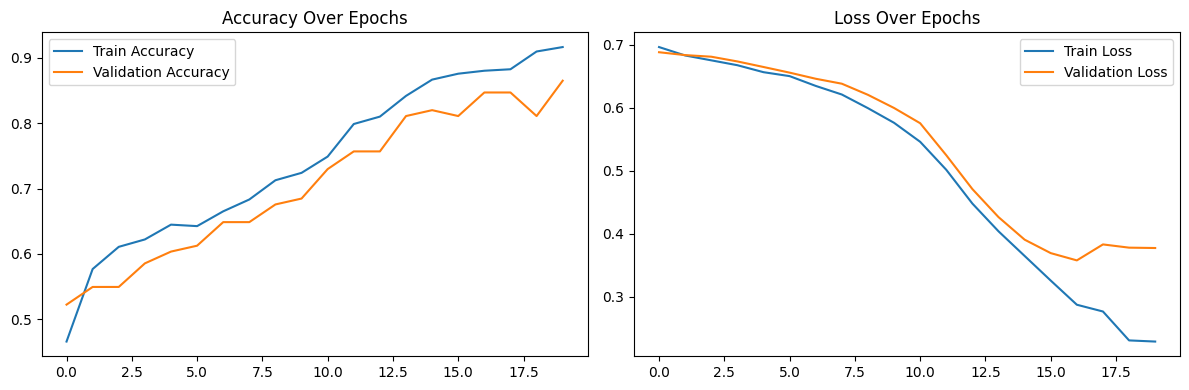

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Data Preparation
def prepare_sequences(df, sequence_length=10, test_size=0.3):
    """Convert packet data into sequences for LSTM"""
    # Scale features
    scaler = StandardScaler()
    X = scaler.fit_transform(df.drop('label', axis=1))
    y = df['label'].values

    # Create sequences
    X_seq, y_seq = [], []
    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i+sequence_length])
        y_seq.append(y[i+sequence_length-1])  # Label for last packet in sequence

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_seq, y_seq, test_size=test_size, random_state=42
    )

    return X_train, X_test, y_train, y_test, scaler

# 2. LSTM Model Definition
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )
    return model

# 3. Training with Early Stopping
def train_lstm(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=64):
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    return history

# 4. Evaluation
def evaluate_model(model, X_test, y_test):
    results = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {results[1]:.4f}")
    print(f"Test Precision: {results[2]:.4f}")
    print(f"Test Recall: {results[3]:.4f}")
    return results

# 5. Plot Training Metrics
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Main Execution
if __name__ == "__main__":
    # Load your preprocessed data
    df = pd.read_csv('unsw_selected_features.csv')

    # Prepare sequential data
    X_train, X_test, y_train, y_test, scaler = prepare_sequences(df, sequence_length=10)

    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    # Build model
    input_shape = (X_train.shape[1], X_train.shape[2])
    lstm_model = build_lstm_model(input_shape)
    lstm_model.summary()

    # Train model
    history = train_lstm(lstm_model, X_train, y_train, X_val, y_val)

    # Evaluate
    test_results = evaluate_model(lstm_model, X_test, y_test)

    # Plot training progress
    plot_training_history(history)

    # Save model for ensemble
    lstm_model.save('lstm_defender.h5')

## CNN model

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv('unsw_selected_features.csv')

# Separate features (X) and labels (y)
X = df.drop(columns=['label'])  # Assuming 'label' column exists
y = df['label'].values

# Normalize features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN input: (samples, timesteps, features)
# Treat each feature as a timestep (e.g., 49 features -> shape=(None, 49, 1))
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.3, random_state=42)

def build_cnn_model(input_shape=(49, 1), num_classes=2):
    """
    Adjusted CNN model for tabular UNSW-NB15 features.
    input_shape: (number_of_features, 1)
    """
    inputs = Input(shape=input_shape)

    # Convolutional blocks
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # Classifier
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and train the model
model = build_cnn_model(input_shape=(X_train.shape[1], 1))
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,882 (2.48 MB)

 Trainable params: 649,986 (2.48 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.7151 - loss: 0.8380 - val_accuracy: 0.6292 - val_loss: 0.6729
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8795 - loss: 0.3616 - val_accuracy: 0.5125 - val_loss: 0.6709
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8847 - loss: 0.3430 - val_accuracy: 0.5125 - val_loss: 0.7186
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8434 - loss: 0.4543 - val_accuracy: 0.5125 - val_loss: 0.7800
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8890 - loss: 0.2542 - val_accuracy: 0.5125 - val_loss: 0.8766
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5133 - loss: 0.8802 
Test Accuracy: 0.5125


In [ ]:
model.save('cnn_defender.h5')  # Saves architecture, weights, and optimizer state
print("CNN model saved as 'cnn_defender.h5'")

# Optional: Save the scaler for preprocessing new data
import joblib
joblib.dump(scaler, 'cnn_scaler.pkl')
print("Scaler saved as 'cnn_scaler.pkl'")

CNN model saved as 'cnn_defender.h5'
Scaler saved as 'cnn_scaler.pkl'


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('unsw_selected_features.csv')

# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize models with recommended parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # Handles class imbalance
)

svm_model = SVC(
    C=1.0,
    kernel='rbf',
    probability=True,  # Required for predict_proba
    random_state=42,
    class_weight='balanced'
)

# Train Random Forest
print("Training Random Forest...")
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Results:")
print(classification_report(y_test, rf_pred))

# Train SVM
print("\nTraining SVM...")
svm_model.fit(X_train, y_train) # Corrected y_train to y_test
svm_pred = svm_model.predict(X_test)
print("SVM Results:")
print(classification_report(y_test, svm_pred))

# Save models and scaler
joblib.dump(rf_model, 'random_forest.pkl')
joblib.dump(svm_model, 'svm.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModels and scaler saved successfully:")
print("- random_forest.pkl")
print("- svm.pkl")
print("- scaler.pkl")

# Verify model loading (optional)
try:
    loaded_rf = joblib.load('random_forest.pkl')
    loaded_svm = joblib.load('svm.pkl')
    loaded_scaler = joblib.load('scaler.pkl')
    print("\nModel and scaler loading verified successfully!")
except Exception as e:
    print(f"\nError loading models or scaler: {e}")

Training Random Forest...
Random Forest Results:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        80
           1       0.95      0.90      0.92        80

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.92       160
weighted avg       0.93      0.93      0.92       160


Training SVM...
SVM Results:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89        80
           1       0.85      0.97      0.91        80

    accuracy                           0.90       160
   macro avg       0.91      0.90      0.90       160
weighted avg       0.91      0.90      0.90       160


Models and scaler saved successfully:
- random_forest.pkl
- svm.pkl
- scaler.pkl

Model and scaler loading verified successfully!


## Ensamble model

In [26]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

class AdaptiveDefenseEnsemble:
    def __init__(self, threshold=0.5, update_freq=25):
        self.threshold = threshold
        self.update_freq = update_freq
        self.buffer = []
        self.packet_counter = 0
        self.true_labels = []
        self.predicted_scores = []
        self.has_retrained = False  # Flag to track if retrained
        self.metrics_history = {
            'detection_rate': [],
            'false_positive_rate': [],
            'false_negative_rate': [],
            'f1_score': [],
            'threshold_adjustments': []
        }

        # Load models and scalers
        self.base_models = self._initialize_base_models()
        self.meta_learner = XGBClassifier()
        self.rf_svm_scaler = joblib.load('scaler.pkl')
        self.cnn_scaler = joblib.load('cnn_scaler.pkl')
        self.lstm_scaler = self.rf_svm_scaler

        # Load balanced subset of dataset
        df = pd.read_csv('unsw_selected_features.csv')
        df_attack = df[df['label'] == 1].sample(n=100, random_state=42)
        df_benign = df[df['label'] == 0].sample(n=100, random_state=42)
        df_subset = pd.concat([df_attack, df_benign]).sample(frac=1, random_state=42)

        self.X_train_full = df_subset.drop(columns=['label']).values
        self.y_train_full = df_subset['label'].values

        print("[INFO] Preparing initial meta-learner training data...")
        meta_X = np.array([self.predict_ensemble(x) for x in self.X_train_full])
        col_means = np.nanmean(meta_X, axis=0)
        for row, col in zip(*np.where(np.isnan(meta_X))):
            meta_X[row, col] = col_means[col]
        self.meta_learner.fit(meta_X, self.y_train_full)
        print("[INFO] Initial meta-learner trained.")

    def _initialize_base_models(self):
        models = {}
        models['lstm'] = load_model('lstm_defender.h5')
        models['cnn'] = load_model('cnn_defender.h5')
        models['random_forest'] = joblib.load('random_forest.pkl')
        models['svm'] = joblib.load('svm.pkl')
        return models

    def predict_ensemble(self, packet):
        predictions = []
        packet_2d = packet.reshape(1, -1)

        # LSTM prediction
        try:
            lstm_scaled = self.lstm_scaler.transform(packet_2d)
            lstm_input = np.repeat(lstm_scaled, 10, axis=0).reshape(1, 10, -1)
            lstm_pred = self.base_models['lstm'].predict(lstm_input)[0][0]
            predictions.append(lstm_pred)
        except Exception as e:
            print(f"LSTM prediction error: {e}")
            predictions.append(np.nan)

        # CNN prediction
        try:
            cnn_scaled = self.cnn_scaler.transform(packet_2d).reshape(1, -1, 1)
            cnn_pred = self.base_models['cnn'].predict(cnn_scaled)[0][1]
            predictions.append(cnn_pred)
        except Exception as e:
            print(f"CNN prediction error: {e}")
            predictions.append(np.nan)

        # Random Forest prediction
        try:
            rf_pred = self.base_models['random_forest'].predict_proba(
                self.rf_svm_scaler.transform(packet_2d))[0][1]
            predictions.append(rf_pred)
        except Exception as e:
            print(f"RF prediction error: {e}")
            predictions.append(np.nan)

        # SVM prediction
        try:
            svm_pred = self.base_models['svm'].predict_proba(
                self.rf_svm_scaler.transform(packet_2d))[0][1]
            predictions.append(svm_pred)
        except Exception as e:
            print(f"SVM prediction error: {e}")
            predictions.append(np.nan)

        return np.array(predictions)

    def update_models(self):
        """Retrain meta-learner exactly once"""
        if self.has_retrained:
            return

        print("\n[INFO] Performing one-time meta-learner retraining...")
        X_buffer = np.array([b[0] for b in self.buffer])
        y_buffer = np.array([b[1] for b in self.buffer])

        # Combine original training data with buffer
        X_combined = np.vstack([self.X_train_full, X_buffer])
        y_combined = np.concatenate([self.y_train_full, y_buffer])

        # Generate meta-features
        meta_X = np.array([self.predict_ensemble(x) for x in X_combined])

        # Handle NaN values
        col_means = np.nanmean(meta_X, axis=0)
        for row, col in zip(*np.where(np.isnan(meta_X))):
            meta_X[row, col] = col_means[col]

        # Retrain meta-learner
        self.meta_learner.fit(meta_X, y_combined)
        self.has_retrained = True
        print("[INFO] One-time retraining completed.")

    def _calculate_metrics(self):
        """Calculate performance metrics"""
        if len(self.true_labels) == 0:
            return 0, 0, 0, 0

        y_true = np.array(self.true_labels)
        y_pred = (np.array(self.predicted_scores) > self.threshold).astype(int)

        detection_rate = recall_score(y_true, y_pred, zero_division=0)

        fp = np.sum((y_pred == 1) & (y_true == 0))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

        fn = np.sum((y_pred == 0) & (y_true == 1))
        tp = np.sum((y_pred == 1) & (y_true == 1))
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

        f1 = f1_score(y_true, y_pred, zero_division=0)

        return detection_rate, false_positive_rate, false_negative_rate, f1

    def process_packet_stream(self, X_stream, y_stream):
        """Process stream with one-time retraining"""
        for i, packet in enumerate(X_stream):
            self.packet_counter += 1

            # Get ensemble predictions
            base_preds = self.predict_ensemble(packet)
            if np.isnan(base_preds).any():
                continue

            # Meta-learner decision
            meta_score = self.meta_learner.predict_proba(base_preds.reshape(1, -1))[0][1]
            self.predicted_scores.append(meta_score)
            self.true_labels.append(y_stream[i])

            # Store in buffer (for potential retraining)
            if not self.has_retrained:
                self.buffer.append((packet, y_stream[i]))

                # Check if we should retrain
                if len(self.buffer) >= self.update_freq:
                    self.update_models()
                    self._adjust_threshold()

            # Calculate and store metrics after each packet
            dr, fpr, fnr, f1 = self._calculate_metrics()
            self.metrics_history['detection_rate'].append(dr)
            self.metrics_history['false_positive_rate'].append(fpr)
            self.metrics_history['false_negative_rate'].append(fnr)
            self.metrics_history['f1_score'].append(f1)
            self.metrics_history['threshold_adjustments'].append(self.threshold)

    def _adjust_threshold(self):
        """Adjust threshold based on recent performance"""
        if len(self.metrics_history['false_positive_rate']) == 0:
            return

        fpr = self.metrics_history['false_positive_rate'][-1]
        fnr = self.metrics_history['false_negative_rate'][-1]

        if fpr > 0.05:
            self.threshold = min(0.9, self.threshold + 0.01)
        elif fnr > 0.1:
            self.threshold = max(0.1, self.threshold - 0.01)

    def plot_performance(self):
        """Generate performance graphs"""
        plt.figure(figsize=(15, 10))

        # Detection Rate
        plt.subplot(2, 2, 1)
        plt.plot(self.metrics_history['detection_rate'], 'b-', label='Detection Rate')
        plt.title('Detection Rate Over Packets')
        plt.xlabel('Packet Number')
        plt.ylabel('Rate')
        plt.ylim(0, 1)
        plt.legend()

        # Error Rates
        plt.subplot(2, 2, 2)
        plt.plot(self.metrics_history['false_positive_rate'], 'r-', label='False Positive Rate')
        plt.plot(self.metrics_history['false_negative_rate'], 'g-', label='False Negative Rate')
        plt.title('Error Rates Over Packets')
        plt.xlabel('Packet Number')
        plt.ylabel('Rate')
        plt.ylim(0, 1)
        plt.legend()

        # F1 Score
        plt.subplot(2, 2, 3)
        plt.plot(self.metrics_history['f1_score'], 'm-', label='F1 Score')
        plt.title('F1 Score Over Packets')
        plt.xlabel('Packet Number')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.legend()

        # Threshold Adjustments
        plt.subplot(2, 2, 4)
        plt.plot(self.metrics_history['threshold_adjustments'], 'k-', label='Threshold')
        plt.title('Decision Threshold Over Packets')
        plt.xlabel('Packet Number')
        plt.ylabel('Threshold')
        plt.ylim(0, 1)
        plt.legend()

        plt.tight_layout()
        plt.show()

# Usage Example
if __name__ == '__main__':
    # Load data
    df = pd.read_csv('unsw_selected_features.csv')
    X = df.drop(columns=['label']).values
    y = df['label'].values

    # Use first 200 samples as simulated adversarial stream
    X_stream = X[:200]
    y_stream = y[:200]

    # Initialize and run defense system
    print("Initializing defense system...")
    defense = AdaptiveDefenseEnsemble(threshold=0.6, update_freq=25)

    print("Processing packet stream...")
    defense.process_packet_stream(X_stream, y_stream)

    # print("Generating performance graphs...")
    # defense.plot_performance()

    # Print final metrics
    if defense.metrics_history['detection_rate']:
        final_dr = defense.metrics_history['detection_rate'][-1]
        final_fpr = defense.metrics_history['false_positive_rate'][-1]
        final_f1 = defense.metrics_history['f1_score'][-1]
        print(f"\nFinal Metrics:")
        print(f"- Detection Rate: {final_dr:.4f}")
        print(f"- False Positive Rate: {final_fpr:.4f}")
        print(f"- F1 Score: {final_f1:.4f}")

Initializing defense system...
[INFO] Preparing initial meta-learner training data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
